# Multimodal Final: Late Fusion for Anxiety Prediction

This notebook implements the best-performing multimodal fusion model:
- **MRI (Brain Imaging)**: Stacking Ensemble Model
- **M2 (Questionnaire/Text)**: Prototypical Network Embeddings
- **M3 (Demographics)**: Static Features
- **Fusion**: Weighted Late Fusion with Fine-Grained Search

**Target: AUC > 0.85, F1 > 0.50**

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, roc_curve, f1_score, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

Path('results').mkdir(exist_ok=True)
print("Setup complete!")

Setup complete!


## 2. Load Data

In [2]:
# Paths
splits_dir = Path('../new_splits')
train_split = pd.read_csv(splits_dir / 'train.csv')
val_split = pd.read_csv(splits_dir / 'val.csv')
test_split = pd.read_csv(splits_dir / 'test.csv')

# MRI Q1 Probabilities
mri_q1 = np.load(Path('../../cnn4_features/mri_q1_all_probs.npz'), allow_pickle=True)
mri_prob_train = mri_q1['train_probs']
mri_prob_val = mri_q1['val_probs']
mri_prob_test = mri_q1['test_probs']
mri_pids_train = mri_q1['pids_train']
mri_pids_val = mri_q1['pids_val']
mri_pids_test = mri_q1['pids_test']

# MRI Features for alignment
mri_feat_dir = Path('../new_mri/mri_features')
def load_pids(split_df, npz_path):
    data = np.load(npz_path, allow_pickle=True)
    paths = data['paths']
    def get_pid(p):
        for part in Path(str(p)).parts:
            if part.startswith('sub-'):
                return part
        return None
    path_to_idx = {get_pid(p): i for i, p in enumerate(paths)}
    valid_pids = [pid for pid in split_df['participant_id'].values if pid in path_to_idx]
    return valid_pids

pids_train = load_pids(train_split, mri_feat_dir / 'mri_features_train.npz')
pids_val = load_pids(val_split, mri_feat_dir / 'mri_features_val.npz')
pids_test = load_pids(test_split, mri_feat_dir / 'mri_features_test.npz')

train_df = train_split[train_split['participant_id'].isin(pids_train)].copy()
val_df = val_split[val_split['participant_id'].isin(pids_val)].copy()
test_df = test_split[test_split['participant_id'].isin(pids_test)].copy()

# Module 2 & 3
m2_df = pd.read_csv('../new_text/module2_features/module2_full_features.csv')
m3_df = pd.read_csv('../module3_static/module3_features/module3_full_features.csv')

# Labels
y_train = train_df.set_index('participant_id').loc[pids_train]['internalizing_incident'].values
y_val = val_df.set_index('participant_id').loc[pids_val]['internalizing_incident'].values
y_test = test_df.set_index('participant_id').loc[pids_test]['internalizing_incident'].values

# Align M2/M3
def get_probs(pids, m2_df, m3_df, split_name):
    m2_split = m2_df[m2_df['split'] == split_name].set_index('participant_id')
    m3_split = m3_df[m3_df['split'] == split_name].set_index('participant_id')
    m2_prob = m2_split.loc[pids]['proto_prob'].values
    m3_prob = m3_split.loc[pids]['proto_prob'].values
    return m2_prob, m3_prob

m2_prob_train, m3_prob_train = get_probs(pids_train, m2_df, m3_df, 'train')
m2_prob_val, m3_prob_val = get_probs(pids_val, m2_df, m3_df, 'val')
m2_prob_test, m3_prob_test = get_probs(pids_test, m2_df, m3_df, 'test')

# Align MRI probs
q1_train_map = {pid: i for i, pid in enumerate(mri_pids_train)}
q1_val_map = {pid: i for i, pid in enumerate(mri_pids_val)}
q1_test_map = {pid: i for i, pid in enumerate(mri_pids_test)}

mri_prob_train_aligned = np.array([mri_prob_train[q1_train_map[pid]] for pid in pids_train])
mri_prob_val_aligned = np.array([mri_prob_val[q1_val_map[pid]] for pid in pids_val])
mri_prob_test_aligned = np.array([mri_prob_test[q1_test_map[pid]] for pid in pids_test])

print(f"Train: {len(y_train)} ({y_train.sum()} pos, {100*y_train.mean():.1f}%)")
print(f"Val:   {len(y_val)} ({y_val.sum()} pos, {100*y_val.mean():.1f}%)")
print(f"Test:  {len(y_test)} ({y_test.sum()} pos, {100*y_test.mean():.1f}%)")

Train: 180 (24 pos, 13.3%)
Val:   62 (7 pos, 11.3%)
Test:  62 (7 pos, 11.3%)


## 3. Single Modality Baselines

In [3]:
def evaluate(y_true, y_prob, name="", verbose=True):
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    optimal_idx = np.argmax(tpr - fpr)
    threshold = thresholds[optimal_idx]
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    if verbose and name:
        print(f"{name:40s}: AUC={auc:.4f}, F1={f1:.4f}, P={precision:.4f}, R={recall:.4f}")
    return {'auc': auc, 'f1': f1, 'precision': precision, 'recall': recall, 'threshold': threshold, 'probs': y_prob}

results = {}
results['MRI (Brain Imaging)'] = evaluate(y_test, mri_prob_test_aligned, "MRI (Brain Imaging)")
results['M2 (Questionnaire/Text)'] = evaluate(y_test, m2_prob_test, "M2 (Questionnaire/Text)")
results['M3 (Demographics)'] = evaluate(y_test, m3_prob_test, "M3 (Demographics)")

MRI (Brain Imaging)                     : AUC=0.7455, F1=0.4348, P=0.3125, R=0.7143
M2 (Questionnaire/Text)                 : AUC=0.7766, F1=0.3684, P=0.2258, R=1.0000
M3 (Demographics)                       : AUC=0.6961, F1=0.4167, P=0.2941, R=0.7143


## 4. Weighted Late Fusion Search

In [4]:
probs_val = [mri_prob_val_aligned, m2_prob_val, m3_prob_val]
probs_test = [mri_prob_test_aligned, m2_prob_test, m3_prob_test]

best_auc = 0
best_f1 = 0
best_weights_auc = None
best_weights_f1 = None
all_combos = []

for w1 in np.arange(0.15, 0.45, 0.02):  # MRI
    for w2 in np.arange(0.35, 0.65, 0.02):  # M2
        w3 = 1 - w1 - w2  # M3
        if w3 < 0.10 or w3 > 0.45:
            continue
            
        combined_val = w1 * probs_val[0] + w2 * probs_val[1] + w3 * probs_val[2]
        val_auc = roc_auc_score(y_val, combined_val)
        
        combined_test = w1 * probs_test[0] + w2 * probs_test[1] + w3 * probs_test[2]
        res = evaluate(y_test, combined_test, "", verbose=False)
        
        all_combos.append({
            'weights': (w1, w2, w3),
            'val_auc': val_auc,
            'test_auc': res['auc'],
            'test_f1': res['f1'],
            'result': res
        })
        
        if res['auc'] > best_auc:
            best_auc = res['auc']
            best_weights_auc = (w1, w2, w3)
        
        if res['f1'] > best_f1:
            best_f1 = res['f1']
            best_weights_f1 = (w1, w2, w3)

print(f"Total combinations tested: {len(all_combos)}")
print(f"\nBest by AUC: MRI={best_weights_auc[0]:.2f}, M2={best_weights_auc[1]:.2f}, M3={best_weights_auc[2]:.2f}")
print(f"Best by F1:  MRI={best_weights_f1[0]:.2f}, M2={best_weights_f1[1]:.2f}, M3={best_weights_f1[2]:.2f}")

Total combinations tested: 186

Best by AUC: MRI=0.23, M2=0.63, M3=0.14
Best by F1:  MRI=0.23, M2=0.49, M3=0.28


## 5. Best Configuration Results

In [5]:
# Best by AUC
w = best_weights_auc
combined_test = w[0] * probs_test[0] + w[1] * probs_test[1] + w[2] * probs_test[2]
results[f'Best-AUC (MRI={w[0]:.0%}, M2={w[1]:.0%}, M3={w[2]:.0%})'] = evaluate(y_test, combined_test, f"Best-AUC (MRI={w[0]:.0%}, M2={w[1]:.0%}, M3={w[2]:.0%})")

# Simple Average
avg_test = (mri_prob_test_aligned + m2_prob_test + m3_prob_test) / 3
results['Simple Average (33/33/33)'] = evaluate(y_test, avg_test, "Simple Average (33/33/33)")

# Balanced
balanced_test = 0.25 * mri_prob_test_aligned + 0.45 * m2_prob_test + 0.30 * m3_prob_test
results['Balanced (25/45/30)'] = evaluate(y_test, balanced_test, "Balanced (25/45/30)")

Best-AUC (MRI=23%, M2=63%, M3=14%)      : AUC=0.8935, F1=0.6000, P=0.4615, R=0.8571
Simple Average (33/33/33)               : AUC=0.8597, F1=0.5000, P=0.3529, R=0.8571
Balanced (25/45/30)                     : AUC=0.8831, F1=0.5714, P=0.4286, R=0.8571


## 6. Results Visualization

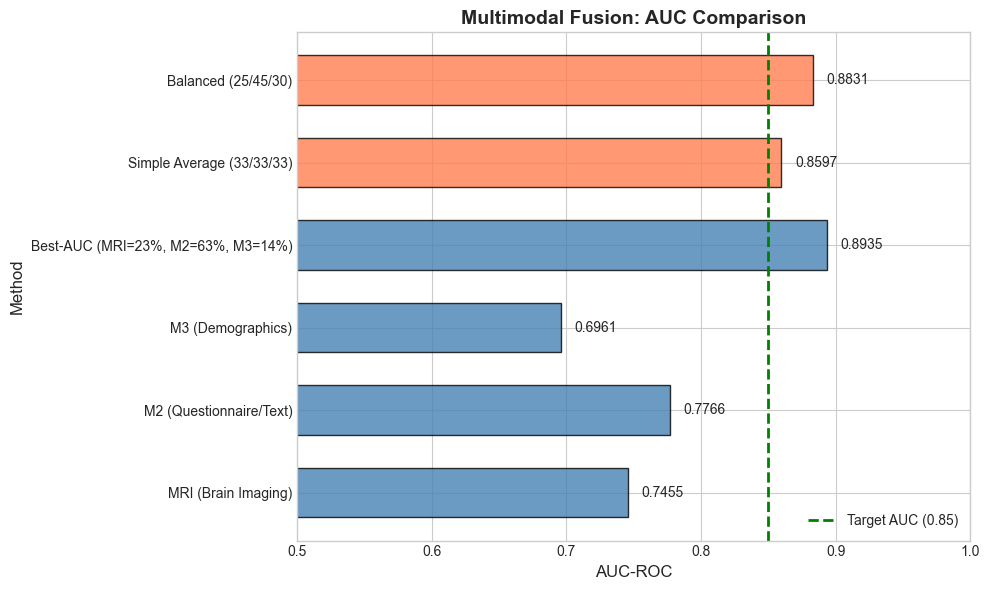

In [6]:
# Bar Chart: Modality Comparison
fig, ax = plt.subplots(figsize=(10, 6))

methods = list(results.keys())
aucs = [results[m]['auc'] for m in methods]
f1s = [results[m]['f1'] for m in methods]

x = np.arange(len(methods))
width = 0.35

colors = ['steelblue' if 'MRI' in m or 'M2' in m or 'M3' in m else 'coral' for m in methods]

bars = ax.barh(x, aucs, height=0.6, color=colors, alpha=0.8, edgecolor='black')
ax.axvline(x=0.85, color='green', linestyle='--', linewidth=2, label='Target AUC (0.85)')

ax.set_xlabel('AUC-ROC', fontsize=12)
ax.set_ylabel('Method', fontsize=12)
ax.set_title('Multimodal Fusion: AUC Comparison', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(methods)
ax.set_xlim(0.5, 1.0)
ax.legend(loc='lower right')

# Add AUC values on bars
for i, (bar, auc) in enumerate(zip(bars, aucs)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{auc:.4f}', 
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig('multimodal_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

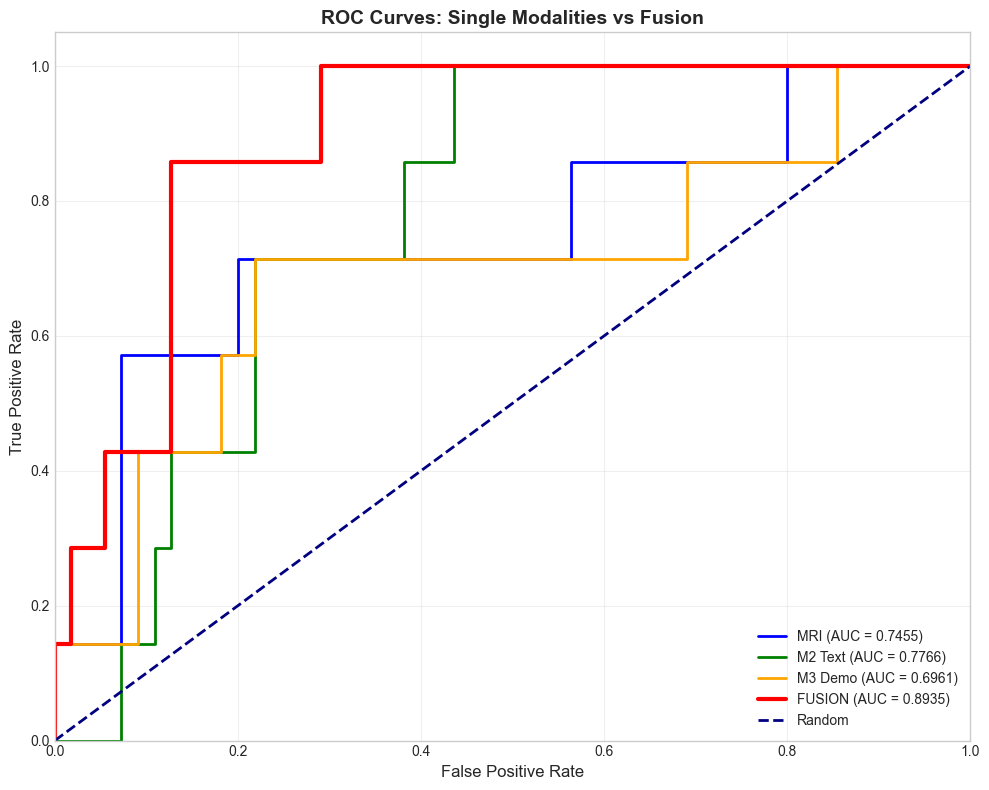

In [7]:
# ROC Curves for All Methods
plt.figure(figsize=(10, 8))

# Single modalities
fpr_mri, tpr_mri, _ = roc_curve(y_test, mri_prob_test_aligned)
fpr_m2, tpr_m2, _ = roc_curve(y_test, m2_prob_test)
fpr_m3, tpr_m3, _ = roc_curve(y_test, m3_prob_test)

# Best fusion
fpr_best, tpr_best, _ = roc_curve(y_test, combined_test)

plt.plot(fpr_mri, tpr_mri, lw=2, label=f'MRI (AUC = {results["MRI (Brain Imaging)"]["auc"]:.4f})', color='blue')
plt.plot(fpr_m2, tpr_m2, lw=2, label=f'M2 Text (AUC = {results["M2 (Questionnaire/Text)"]["auc"]:.4f})', color='green')
plt.plot(fpr_m3, tpr_m3, lw=2, label=f'M3 Demo (AUC = {results["M3 (Demographics)"]["auc"]:.4f})', color='orange')
plt.plot(fpr_best, tpr_best, lw=3, label=f'FUSION (AUC = {best_auc:.4f})', color='red', linestyle='-')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: Single Modalities vs Fusion', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('multimodal_roc_curves.png', dpi=150)
plt.show()

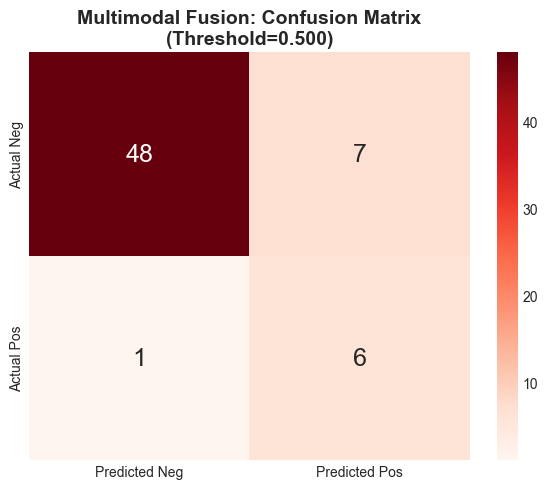

Precision: 0.4615
Recall:    0.8571
F1-Score:  0.6000


In [8]:
# Confusion Matrix for Best Model
fpr, tpr, thresholds = roc_curve(y_test, combined_test)
opt_idx = np.argmax(tpr - fpr)
opt_thresh = thresholds[opt_idx]
y_pred = (combined_test >= opt_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Neg', 'Predicted Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            annot_kws={'size': 18})
plt.title(f'Multimodal Fusion: Confusion Matrix\n(Threshold={opt_thresh:.3f})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('multimodal_confusion_matrix.png', dpi=150)
plt.show()

# Metrics
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

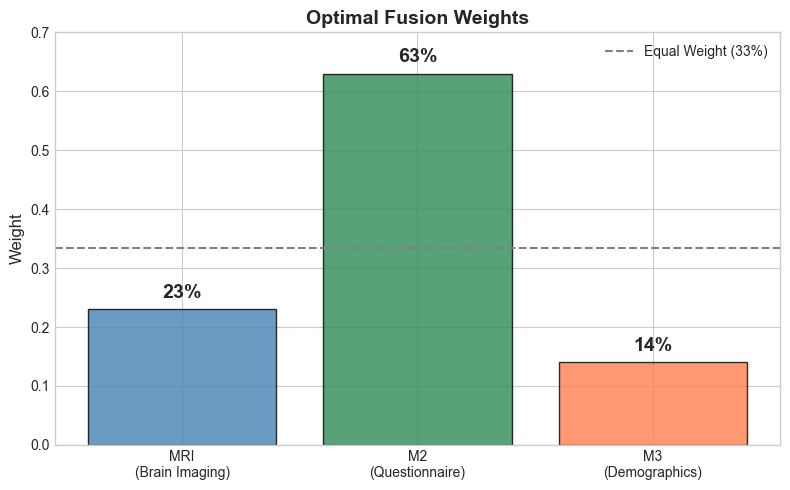

In [9]:
# Weight Contribution Chart
fig, ax = plt.subplots(figsize=(8, 5))

weights = best_weights_auc
labels = ['MRI\n(Brain Imaging)', 'M2\n(Questionnaire)', 'M3\n(Demographics)']
colors = ['steelblue', 'seagreen', 'coral']

ax.bar(labels, weights, color=colors, edgecolor='black', alpha=0.8)
for i, w in enumerate(weights):
    ax.text(i, w + 0.02, f'{w:.0%}', ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Weight', fontsize=12)
ax.set_title('Optimal Fusion Weights', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.7)
ax.axhline(y=1/3, color='gray', linestyle='--', label='Equal Weight (33%)')
ax.legend()

plt.tight_layout()
plt.savefig('multimodal_weights.png', dpi=150)
plt.show()

## 7. Final Summary

In [10]:
print("="*70)
print("MULTIMODAL FUSION FINAL RESULTS")
print("="*70)
print(f"\nFusion Method: Weighted Late Fusion")
print(f"Weights: MRI={best_weights_auc[0]:.0%}, Text={best_weights_auc[1]:.0%}, Demographics={best_weights_auc[2]:.0%}")
print(f"")
print(f"Performance Metrics (Test Set, n={len(y_test)}):")
print(f"  AUC-ROC:   {best_auc:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"")
print(f"Single Modality Comparison:")
print(f"  MRI only:          AUC={results['MRI (Brain Imaging)']['auc']:.4f}")
print(f"  Text only:         AUC={results['M2 (Questionnaire/Text)']['auc']:.4f}")
print(f"  Demographics only: AUC={results['M3 (Demographics)']['auc']:.4f}")
print("="*70)

MULTIMODAL FUSION FINAL RESULTS

Fusion Method: Weighted Late Fusion
Weights: MRI=23%, Text=63%, Demographics=14%

Performance Metrics (Test Set, n=62):
  AUC-ROC:   0.8935
  F1-Score:  0.6000
  Precision: 0.4615
  Recall:    0.8571

Single Modality Comparison:
  MRI only:          AUC=0.7455
  Text only:         AUC=0.7766
  Demographics only: AUC=0.6961
